# Aufgabe
1. Berechne durchschnittliche Zahl der Räume pro Haus pro Wohngebiet.
2. Berechne die Heatmap ausgewählter Werte.
3. Erstelle ein einfaches Decision Tree Model, dass auf Basis der Eingabe ausgewählter Werte einen Immobilienpreis ausgibt.
4. Teste weitere Modelle von scikit-learn.

### CSV auslesen:

In [73]:
import pandas as pd

df = pd.read_csv('cali_data.csv')
df = df.dropna(axis=0)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Durchschnittliche Anzahl der Räume pro Haus ausrechnen und als neue Spalte hinzufügen.

In [74]:
df['avg_rooms'] = df['total_rooms'] / df['households']
df['avg_bedrooms'] = df['total_bedrooms'] / df['households']

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,avg_rooms,avg_bedrooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081


### Korrelation zwischen avg_rooms und median_house_value berechnen

                    avg_rooms  avg_bedrooms  housing_median_age  population  \
avg_rooms            1.000000      0.848616           -0.153031   -0.071898   
avg_bedrooms         0.848616      1.000000           -0.077918   -0.066510   
housing_median_age  -0.153031     -0.077918            1.000000   -0.295787   
population          -0.071898     -0.066510           -0.295787    1.000000   
households          -0.080165     -0.055158           -0.302768    0.907186   
median_income        0.325307     -0.062299           -0.118278    0.005087   
median_house_value   0.151344     -0.046739            0.106432   -0.025300   
latitude             0.106423      0.070025            0.011899   -0.108997   
longitude           -0.027307      0.013402           -0.109357    0.100270   

                    households  median_income  median_house_value  latitude  \
avg_rooms            -0.080165       0.325307            0.151344  0.106423   
avg_bedrooms         -0.055158      -0.062299      

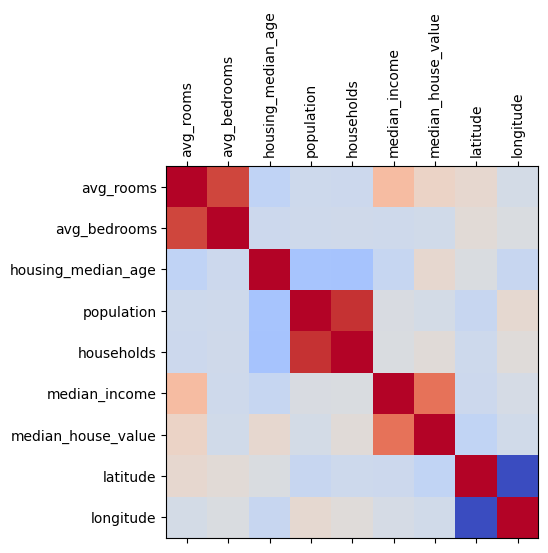

In [75]:
import matplotlib.pyplot as plt

corr = df[['avg_rooms', 'avg_bedrooms', 'housing_median_age', 'population', 'households', 'median_income', 'median_house_value', 'latitude', 'longitude']].corr()

print(corr)

plt.matshow(corr, cmap='coolwarm')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

### Trainings- und Testdaten festlegen

In [76]:
y = df['median_house_value']
x = df[['avg_rooms', 'avg_bedrooms', 'population', 'households', 'median_income', 'latitude', 'longitude', 'housing_median_age']]

from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(x, y, train_size=0.9)

### Entscheidungsbaum-Modell

In [77]:
from sklearn.tree import DecisionTreeRegressor
dec_tree_model = DecisionTreeRegressor()
dec_tree_model.fit(train_x, train_y)

DecisionTreeRegressor()

### Random-Forest-Modell

In [78]:
from sklearn.ensemble import RandomForestRegressor
ran_for_reg_model = RandomForestRegressor()
ran_for_reg_model.fit(train_x, train_y)

RandomForestRegressor()

### Gradient-Boosting-Modell

In [79]:
from sklearn.ensemble import GradientBoostingRegressor
grad_boost_model = GradientBoostingRegressor()
grad_boost_model.fit(train_x, train_y)

GradientBoostingRegressor()

### Ada-Boost-Modell

In [80]:
from sklearn.ensemble import AdaBoostRegressor
ada_boost_model = AdaBoostRegressor()
ada_boost_model.fit(train_x, train_y)

AdaBoostRegressor()

### MLP-Regressor-Modell

In [81]:
from sklearn.neural_network import MLPRegressor
mlp_reg_model = MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
mlp_reg_model.fit(train_x, train_y)

c:\Users\Infi\anaconda3\envs\dssec\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42)

### Modelle bewerten

In [82]:
from sklearn.metrics import mean_absolute_error
print('Entscheidungsbaum:', mean_absolute_error(test_y, dec_tree_model.predict(test_x)))
print('Random Forest:', mean_absolute_error(test_y, ran_for_reg_model.predict(test_x)))
print('Gradient Boosting:', mean_absolute_error(test_y, grad_boost_model.predict(test_x)))
print('Ada Boost:', mean_absolute_error(test_y, ada_boost_model.predict(test_x)))
print('MLPRegressor:', mean_absolute_error(test_y, mlp_reg_model.predict(test_x)))

Entscheidungsbaum: 46124.748532289625
Random Forest: 33456.89872309198
Gradient Boosting: 38752.75135031845
Ada Boost: 85676.25305229913
MLPRegressor: 66875.8178636274
